In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve)
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier as DT
from matplotlib.colors import ListedColormap
from time import perf_counter

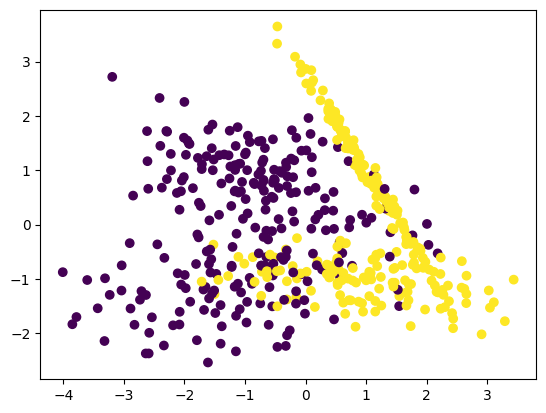

In [53]:
X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=2, n_classes=2, random_state=37)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [54]:
klasyfikatory = {
    "NaiveBayes": GaussianNB(),
    "QDA": QDA(),
    "KNN": KNN(),
    "SVM": SVC(probability=True),
    "Drzewo": DT()
}

def ocen_model(model, X, y, iteracje=100):
    metryki = {
        'acc': [], 'recall': [], 'prec': [], 'f1': [], 'auc': [],
        'czas_fit': [], 'czas_pred': []
    }
    ostatnia_iteracja = {}

    for _ in range(iteracje):
        Xtr, Xts, ytr, yts = train_test_split(X, y, test_size=0.3)

        t1 = perf_counter()
        model.fit(Xtr, ytr)
        t2 = perf_counter()
        yhat = model.predict(Xts)
        t3 = perf_counter()
        yscore = model.predict_proba(Xts)[:, 1]

        metryki['acc'].append(accuracy_score(yts, yhat))
        metryki['recall'].append(recall_score(yts, yhat))
        metryki['prec'].append(precision_score(yts, yhat))
        metryki['f1'].append(f1_score(yts, yhat))
        metryki['auc'].append(roc_auc_score(yts, yscore))
        metryki['czas_fit'].append(t2 - t1)
        metryki['czas_pred'].append(t3 - t2)

        ostatnia_iteracja = dict(model=model, X=Xts, y=yts, y_pred=yhat, y_prob=yscore)

    return pd.Series({m: np.mean(w) for m, w in metryki.items()}), ostatnia_iteracja

Ocena wszystkich modeli

In [55]:
raport = []
ostatnie = {}

for nazwa, klasyfikator in klasyfikatory.items():
    wyniki, ostatni = ocen_model(klasyfikator, X, y)
    wyniki["Model"] = nazwa
    raport.append(wyniki)
    ostatnie[nazwa] = ostatni

df_wynikowy = pd.DataFrame(raport).set_index("Model")
print(df_wynikowy)

                 acc    recall      prec        f1       auc  czas_fit  \
Model                                                                    
NaiveBayes  0.843600  0.880002  0.820158  0.848066  0.906923  0.000230   
QDA         0.849467  0.885595  0.823465  0.852672  0.903528  0.000187   
KNN         0.867733  0.896666  0.848015  0.870652  0.930270  0.000221   
SVM         0.877400  0.901636  0.856634  0.877875  0.938289  0.003967   
Drzewo      0.843533  0.849092  0.842854  0.845145  0.843503  0.000455   

            czas_pred  
Model                  
NaiveBayes   0.000070  
QDA          0.000066  
KNN          0.002015  
SVM          0.000629  
Drzewo       0.000063  


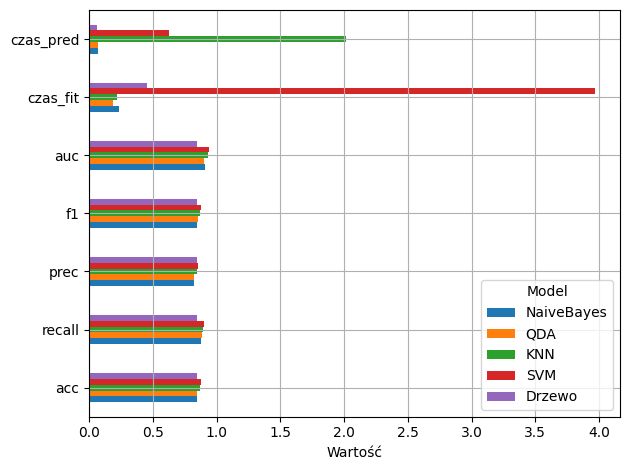

In [56]:
df_wynikowy["czas_fit"] *= 1000
df_wynikowy["czas_pred"] *= 1000

df_wynikowy.T.plot.barh()
plt.xlabel("Wartość")
plt.tight_layout()
plt.grid(True)
plt.show()


/var/folders/t9/w0gv9k2j679b30182g2078dc0000gn/T/ipykernel_4414/627877033.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


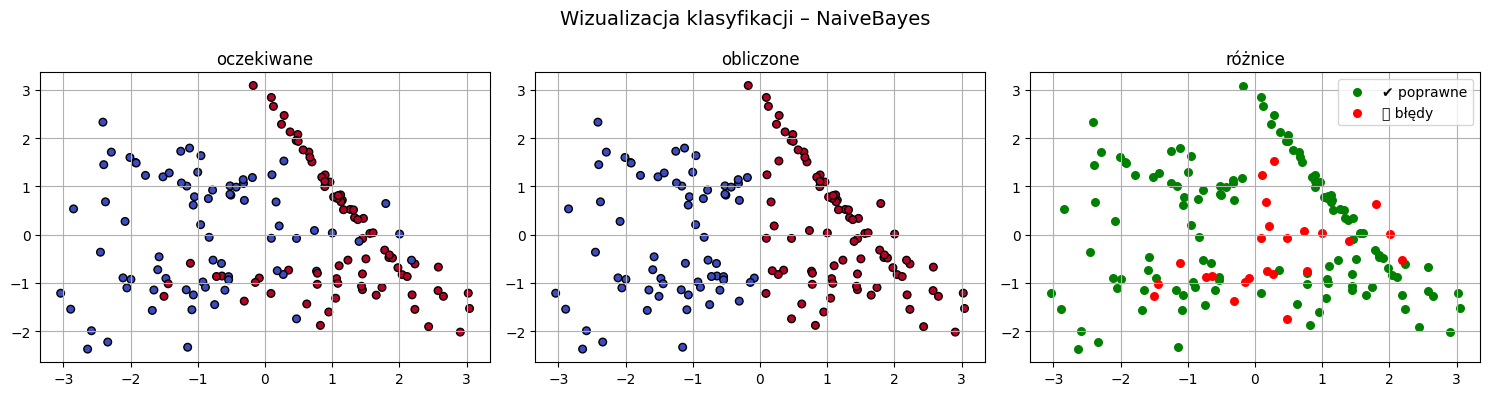

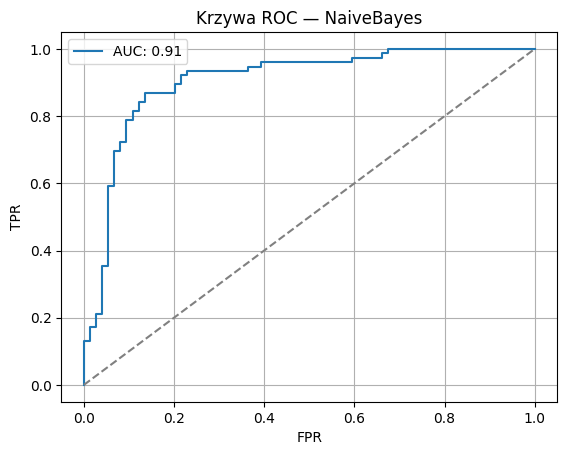

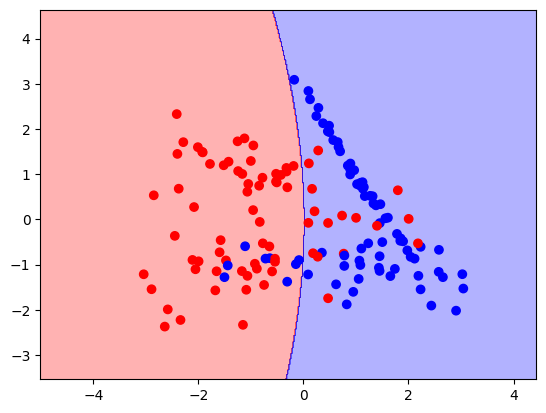

/var/folders/t9/w0gv9k2j679b30182g2078dc0000gn/T/ipykernel_4414/627877033.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


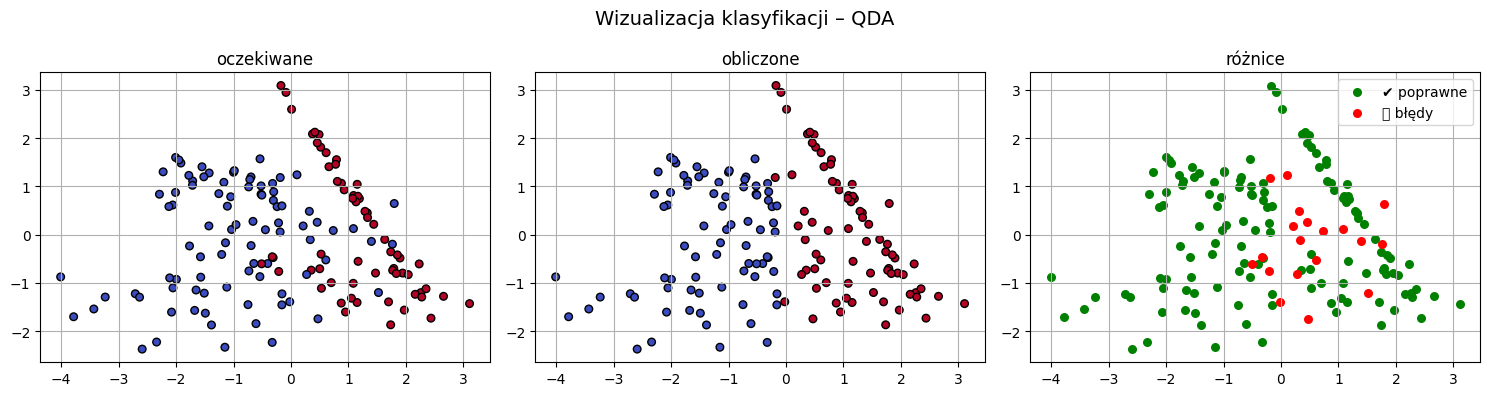

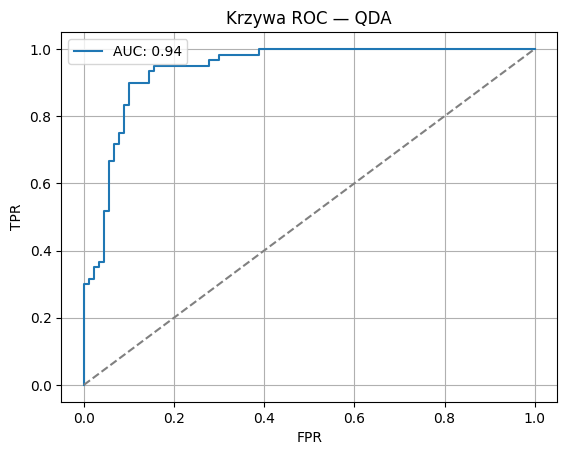

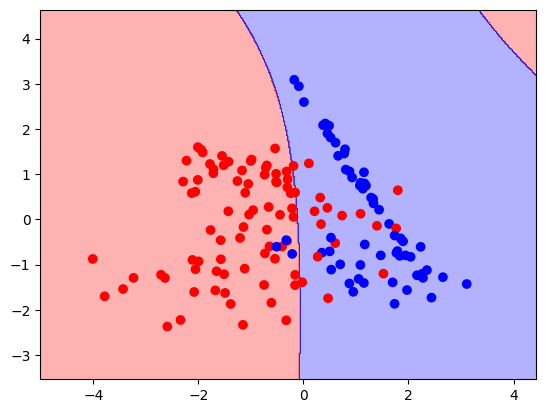

/var/folders/t9/w0gv9k2j679b30182g2078dc0000gn/T/ipykernel_4414/627877033.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


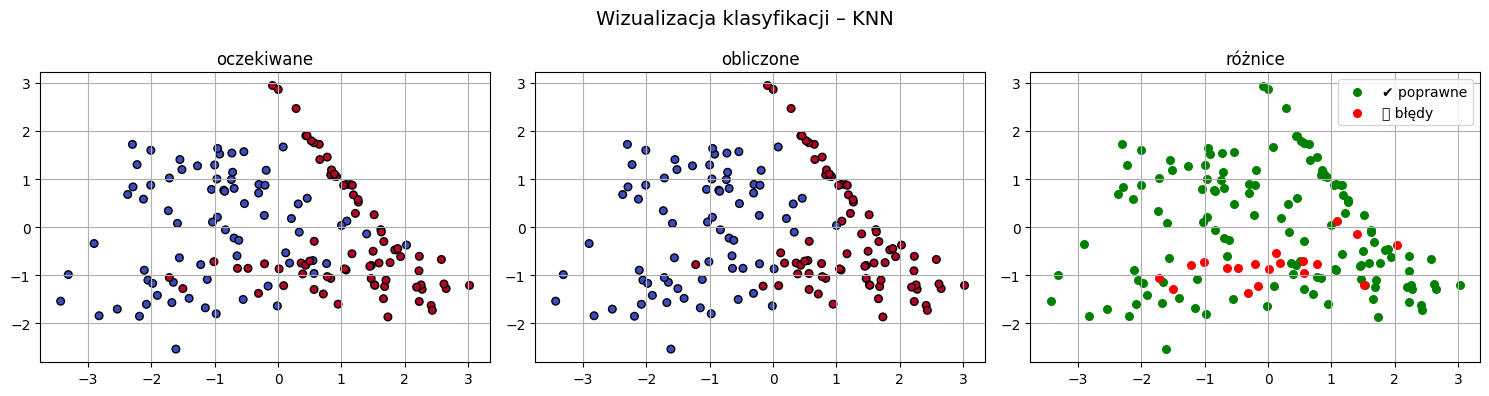

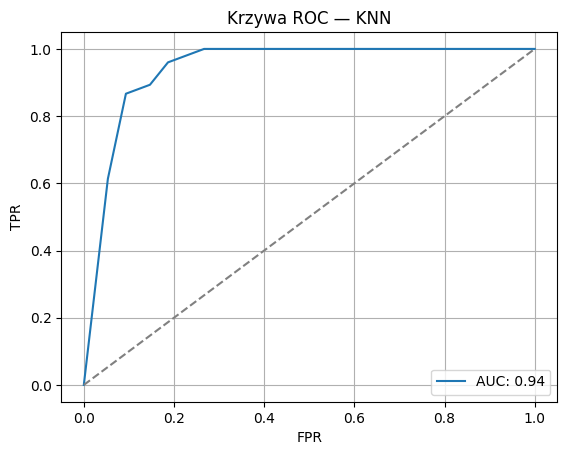

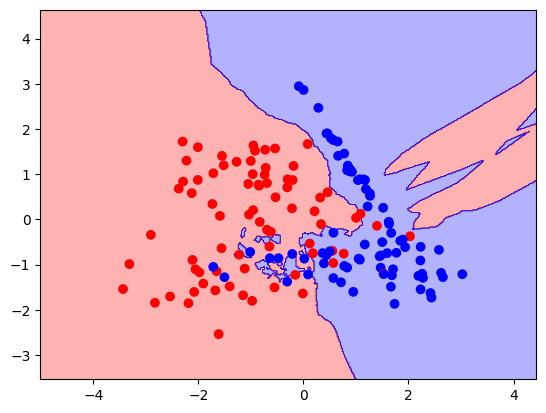

/var/folders/t9/w0gv9k2j679b30182g2078dc0000gn/T/ipykernel_4414/627877033.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


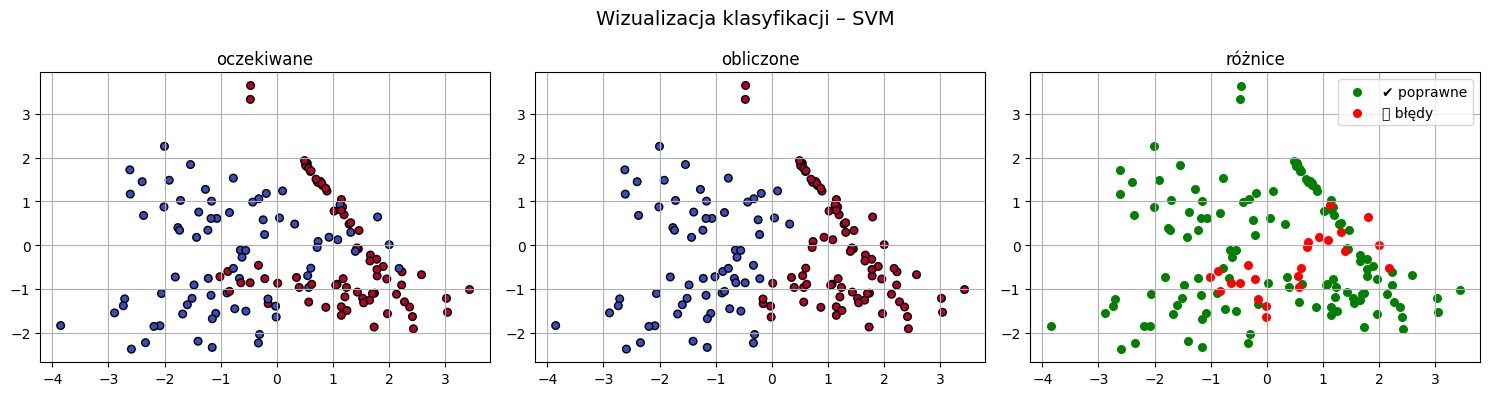

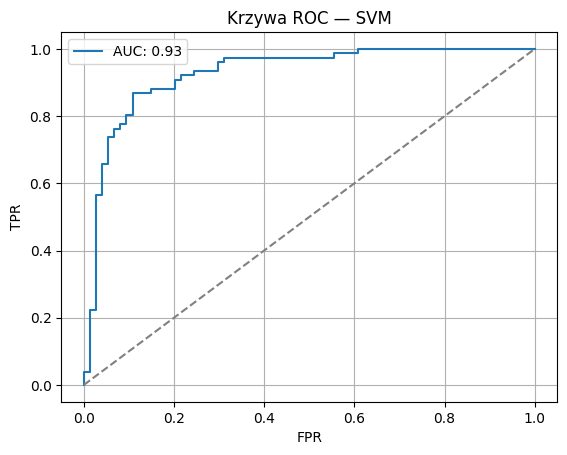

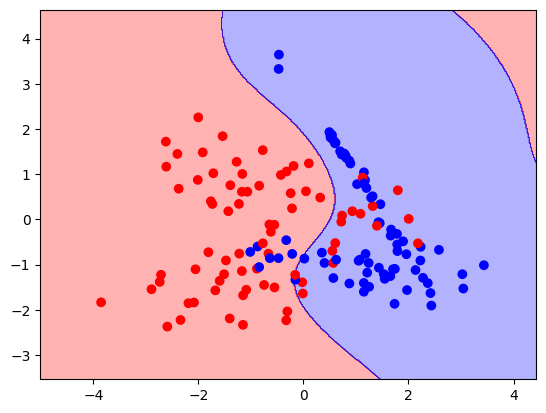

/var/folders/t9/w0gv9k2j679b30182g2078dc0000gn/T/ipykernel_4414/627877033.py:25: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


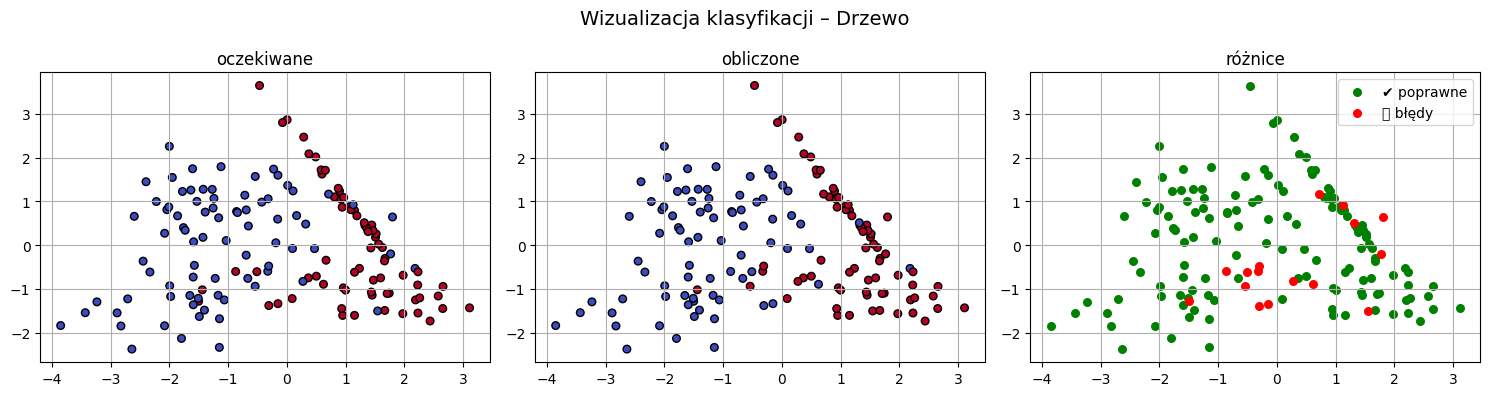

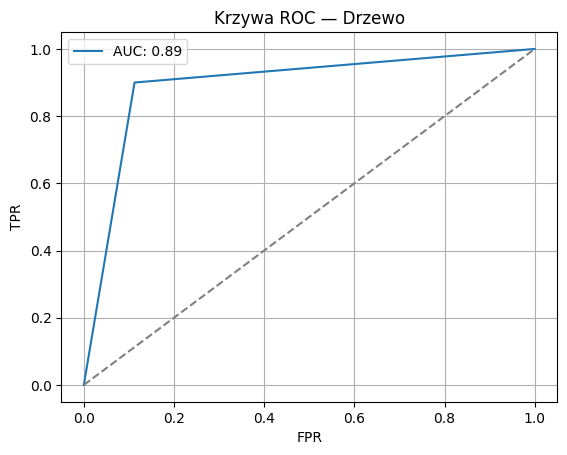

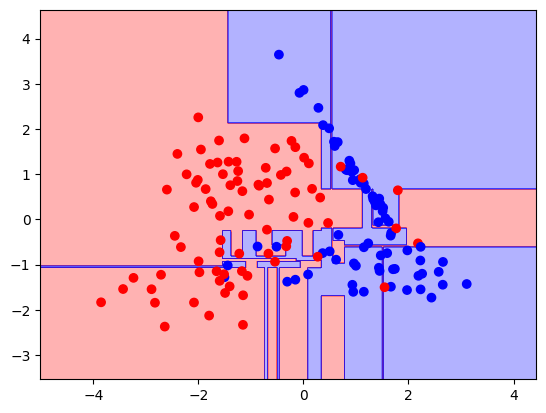

In [57]:
for wybrany in klasyfikatory.keys():
    model_data = ostatnie[wybrany]
    Xtest = model_data["X"]
    ytest = model_data["y"]
    ypred = model_data["y_pred"]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Wizualizacja klasyfikacji – {wybrany}", fontsize=14)

    axs[0].scatter(Xtest[:, 0], Xtest[:, 1], c=ytest, cmap="coolwarm", s=30, edgecolor='k')
    axs[0].set_title("oczekiwane")
    axs[0].grid(True)

    axs[1].scatter(Xtest[:, 0], Xtest[:, 1], c=ypred, cmap="coolwarm", s=30, edgecolor='k')
    axs[1].set_title("obliczone")
    axs[1].grid(True)
    
    maska = ytest == ypred
    axs[2].scatter(Xtest[maska, 0], Xtest[maska, 1], c="green", label="✔️ poprawne", s=30)
    axs[2].scatter(Xtest[~maska, 0], Xtest[~maska, 1], c="red", label="❌ błędy", s=30)
    axs[2].set_title("różnice")
    axs[2].legend()
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()
    
    fpr, tpr, _ = roc_curve(model_data["y"], model_data["y_prob"])
    plt.plot(fpr, tpr, label=f"AUC: {roc_auc_score(model_data['y'], model_data['y_prob']):.2f}")
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.title(f"Krzywa ROC — {wybrany}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    xlim = (X[:, 0].min() - 1, X[:, 0].max() + 1)
    ylim = (X[:, 1].min() - 1, X[:, 1].max() + 1)
    xx, yy = np.meshgrid(np.arange(*xlim, 0.02), np.arange(*ylim, 0.02))
    Z = model_data["model"].predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=ListedColormap(['red', 'blue']), alpha=0.3)
    plt.scatter(model_data["X"][:, 0], model_data["X"][:, 1], c=model_data["y"], cmap=ListedColormap(['red', 'blue']))
    plt.show()

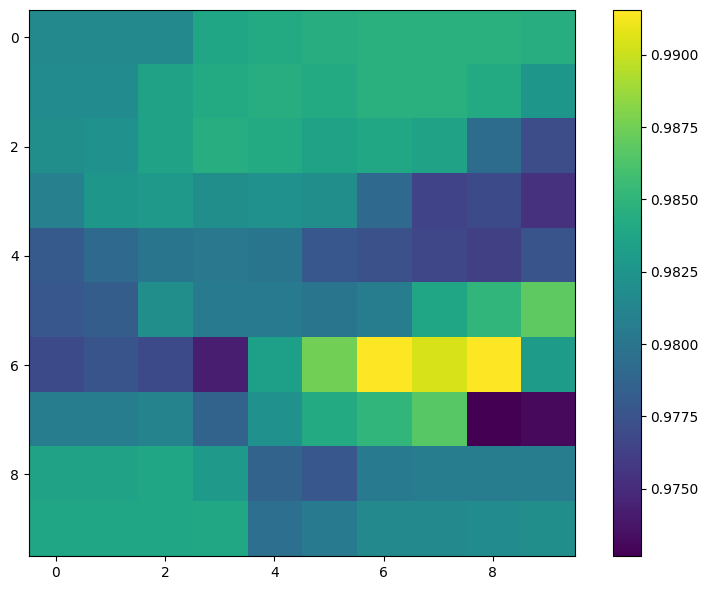

In [58]:
X, y = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, n_classes=2, random_state=21
)

model = SVC(probability=True)

parametry = {
    'C': np.logspace(-2, 2, 10),
    'gamma': np.logspace(-2, 2, 10)
}

grid = GridSearchCV(model, parametry, scoring='roc_auc', cv=5)
grid.fit(X, y)

najlepsze = grid.best_params_

df_auc = pd.DataFrame(grid.cv_results_).pivot(
    index='param_gamma', columns='param_C', values='mean_test_score'
)

plt.figure(figsize=(8, 6))
plt.imshow(df_auc, interpolation='nearest', cmap='viridis')
plt.colorbar()
plt.tight_layout()
plt.show()


In [59]:
finalny = SVC(probability=True, **najlepsze)
wyniki = []

for _ in range(100):
    Xtr, Xts, ytr, yts = train_test_split(X, y, test_size=0.3)

    t1 = perf_counter()
    finalny.fit(Xtr, ytr)
    t2 = perf_counter()

    y_pred = finalny.predict(Xts)
    y_prob = finalny.predict_proba(Xts)[:, 1]
    t3 = perf_counter()

    wyniki.append({
        "acc": accuracy_score(yts, y_pred),
        "recall": recall_score(yts, y_pred),
        "prec": precision_score(yts, y_pred),
        "f1": f1_score(yts, y_pred),
        "auc": roc_auc_score(yts, y_prob),
        "czas_fit [ms]": (t2 - t1) * 1000,
        "czas_pred [ms]": (t3 - t2) * 1000
    })

df_svm = pd.DataFrame(wyniki).mean().to_frame("Średnia").T
df_svm["param_C"] = najlepsze["C"]
df_svm["param_gamma"] = najlepsze["gamma"]

print(df_svm)


              acc    recall      prec        f1       auc  czas_fit [ms]  \
Średnia  0.971667  0.955996  0.986407  0.970643  0.984443       1.668008   

         czas_pred [ms]   param_C  param_gamma  
Średnia        0.409264  4.641589     4.641589  


# Zad 1
1. Sprawdziłem kilka klasyfikatorów: Naive Bayes, QDA, KNN, SVM i drzewo.
2. Puściłem każdy po 100 razy na losowych podziałach i zebrałem metryki.
3. QDA i SVM miały najlepsze wyniki, Naive Bayes był najprostszy i najszybszy.
4. Zrobiłem też wykres z błędami (zielone/czerwone) i granicą decyzyjną — zgodnie z instrukcją, w trzech panelach.

# Zad 2
1. Tutaj dobrałem parametry C i gamma dla SVM-a przez GridSearchCV (pod AUC).
2. Zrobiłem dokładniejszą mapkę AUC (zagęszczona siatka logarytmiczna).
3. Najlepszy model testowałem też 100 razy i wypisałem średnie metryki.
4. Czasy przeliczyłem na milisekundy, żeby dało się je normalnie porównać.

# WNIOSKI
- QDA i SVM to najbardziej skuteczne modele dla tego zbioru.
- Optymalizacja parametrów w SVM (szczególnie gamma) ma duże znaczenie.
- Czas działania też może być kluczowy, np. Naive Bayes działa ekstremalnie szybko.
- Granice decyzyjne i błędy klasyfikacji są dobrze widoczne na wykresach – pomagają zrozumieć działanie modeli.